# A two-sector I-HANK model

**Table of contents**<a id='toc0_'></a>    
- 1. [Setup](#toc1_)    
- 2. [Steady state](#toc2_)    
- 3. [Compute Jacobians](#toc3_)    
- 4. [Foreign demand shock](#toc4_)    
- 5. [Response in consumption to different shocks](#toc5_)    
- 6. [Decomposing consumption response](#toc6_)    
- 7. [Fixed vs floating exchange rate](#toc7_)    
- 8. [Decomposing consumption response under fixed exchange rate](#toc8_)    

<!-- vscode-jupyter-toc-config
	numbering=true
	anchor=true
	flat=false
	minLevel=2
	maxLevel=6
	/vscode-jupyter-toc-config -->
<!-- THIS CELL WILL BE REPLACED ON TOC UPDATE. DO NOT WRITE YOUR TEXT IN THIS CELL -->

In [4]:
%load_ext autoreload
%autoreload 2

import numpy as np
import os #save figures
temp_graphs = "Temporary graphs"
os.makedirs(temp_graphs, exist_ok=True)

final_graphs = "Final graphs"
os.makedirs(final_graphs, exist_ok=True)

import matplotlib.pyplot as plt   
colors = plt.rcParams['axes.prop_cycle'].by_key()['color']
plt.rcParams.update({"axes.grid" : True, "grid.color": "black", "grid.alpha":"0.25", "grid.linestyle": "--"})
plt.rcParams.update({'font.size': 14})

from IHANKModel import IHANKModelClass

model = IHANKModelClass(name='baseline')
par = model.par
ss = model.ss
path = model.path
sim = model.sim

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


## 1. Setup

In [5]:
model.info()

settings:
 par.py_hh = False
 par.py_blocks = False
 par.full_z_trans = False
 par.warnings = True
 par.T = 300

households:
 grids_hh: [a]
 pols_hh: [a]
 inputs_hh: [beta,ra,inc_HH,inc_HL,inc_LH,inc_LL,inc_NT]
 inputs_hh_z: []
 outputs_hh: [a,c,uc_HH,uc_HL,uc_LH,uc_LL,uc_NT,c_HH,c_HL,c_LH,c_LL,c_NT]
 intertemps_hh: [vbeg_a]

aggregate:
 shocks: [ZTH_HH,ZTH_HL,ZTH_LH,ZTH_LL,ZNT,beta,G,i_shock,i_shock_eu,Z_eu,ZNT_eu,i_shock_us,Z_us,ZNT_us,tau_x,tau_m]
 unknowns: [CB,NNT,NHH,NHL,NLH,NLL,piWHH,piWHL,piWLH,piWLL,piWNT,CB_us,C_eu,N_eu,NNT_eu,pi_T_eu,pi_NT_eu,i_eu,mc_eu,C_us,N_us,NNT_us,pi_T_us,pi_NT_us,i_us,mc_us,CTF_us]
 targets: [NKWCHH_res,NKWCHL_res,NKWCLH_res,NKWCLL_res,NKWCNT_res,clearing_YHH,clearing_YHL,clearing_YLH,clearing_YLL,clearing_YNT,eu_Euler_res,eu_NKPC_res,eu_NKPC_NT_res,eu_TR_res,eu_LS_res,eu_RC_res,eu_NT_res,UIP_res,us_Euler_res,us_NKPC_res,us_NKPC_NT_res,us_TR_res,us_LS_res,us_RC_res,us_NT_res,UIP_res_us,CTF_us_res]

blocks (inputs -> outputs):
 mon_pol: [CB,CB_us] -> [

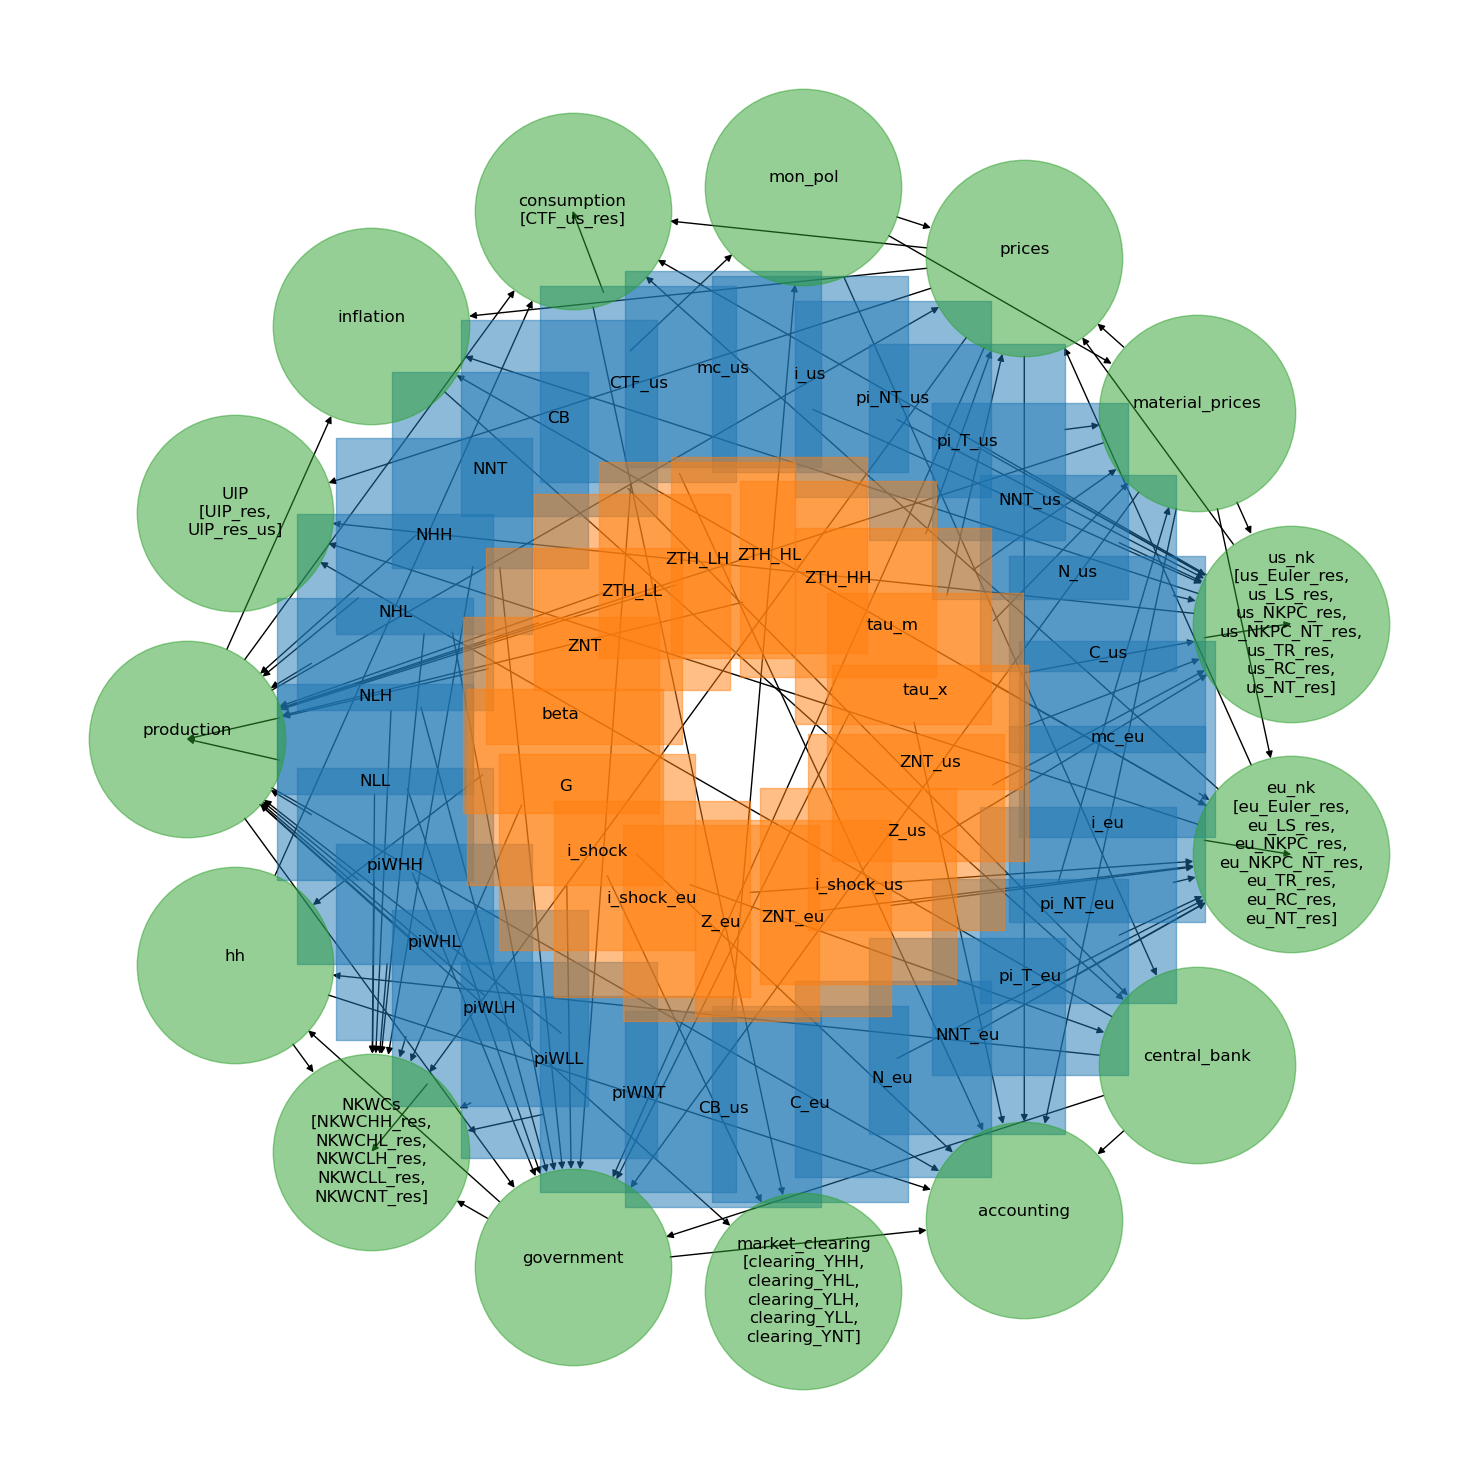

In [6]:
model.draw_DAG(figsize=(15,15),order=['shocks','unknowns','blocks'])

## 2. Steady state

In [11]:
model.find_ss(do_print=True)

  beta = 0.93000  ->  HtM = 1.0000  (target 0.1500)
  beta = 0.99000  ->  HtM = 0.1035  (target 0.1500)
  beta = 0.93000  ->  HtM = 1.0000  (target 0.1500)
  beta = 0.99000  ->  HtM = 0.1035  (target 0.1500)
  beta = 0.98689  ->  HtM = 0.1584  (target 0.1500)
  beta = 0.98736  ->  HtM = 0.1505  (target 0.1500)
  beta = 0.98739  ->  HtM = 0.1500  (target 0.1500)
  beta = 0.98738  ->  HtM = 0.1501  (target 0.1500)
  -> calibrated beta = 0.98739
steady state found in 6.4 secs
ss.inc_HH = 0.225
ss.inc_HL = 0.011
ss.inc_LH = 0.129
ss.inc_LL = 0.047
ss.inc_NT = 0.289
par.alphaT = 0.826
par.alphaF = 0.150
par.omega_TH_HH = 0.565
par.omega_TH_HL = 0.024
par.omega_TH_LH = 0.298
par.omega_TH_LL = 0.113
par.varphiHH = 1.061
par.varphiHL = 0.806
par.varphiLH = 0.832
par.varphiLL = 0.935
par.varphiNT = 1.008
ss.YHH = 0.497
ss.YHL = 0.021
ss.YLH = 0.263
ss.YLL = 0.099
ss.YNT = 0.413
ss.M_eu_s = 0.249
ss.M_us_s = 0.133
ss.clearing_YHH =   0.00000000
ss.clearing_YHL =  -0.00000000
ss.clearing_YLH =   

## 4. <a id='toc4_'></a>[Tests](#toc0_)

In [12]:
model.test_ss()

E              :       1.0000
CB             :       0.0050
E_us           :       1.0000
CB_us          :       1.0000
PM_eu_eu       :       1.0000
PM_us_us       :       1.0000
PM_eu_us       :       1.0000
PM_eu          :       1.0000
PM_us_eu       :       1.0000
PM_us          :       1.0000
PM_dk_eu       :       1.0000
PM_dk_us       :       1.0000
tau_m          :       0.0000
tau_x          :       0.0000
PT_eu_s        :       1.0000
pi_T_eu        :       0.0000
PT_us_s        :       1.0000
pi_T_us        :       0.0000
Z_eu           :       1.0000
ZNT_eu         :       1.0000
i_shock_eu     :       0.0000
Y_eu           :       3.5714
C_eu           :       1.4286
N_eu           :       1.0000
NNT_eu         :       0.4286
pi_NT_eu       :       0.0000
i_eu           :       0.0050
PF_eu_s        :       1.0000
PNT_eu_s       :       1.0000
rF_eu          :       0.0050
M_eu_s         :       0.2487
mc_eu          :       1.0000
W_eu           :       1.0000
C_T_eu    

note: inputs = steady state value -> expected: constant value (straigt line) in roughly -10^-5 to 10^5

household problem solved along transition path in 2.3 secs
household problem simulated along transition in 9.7 secs



NameError: name 'folder_us' is not defined

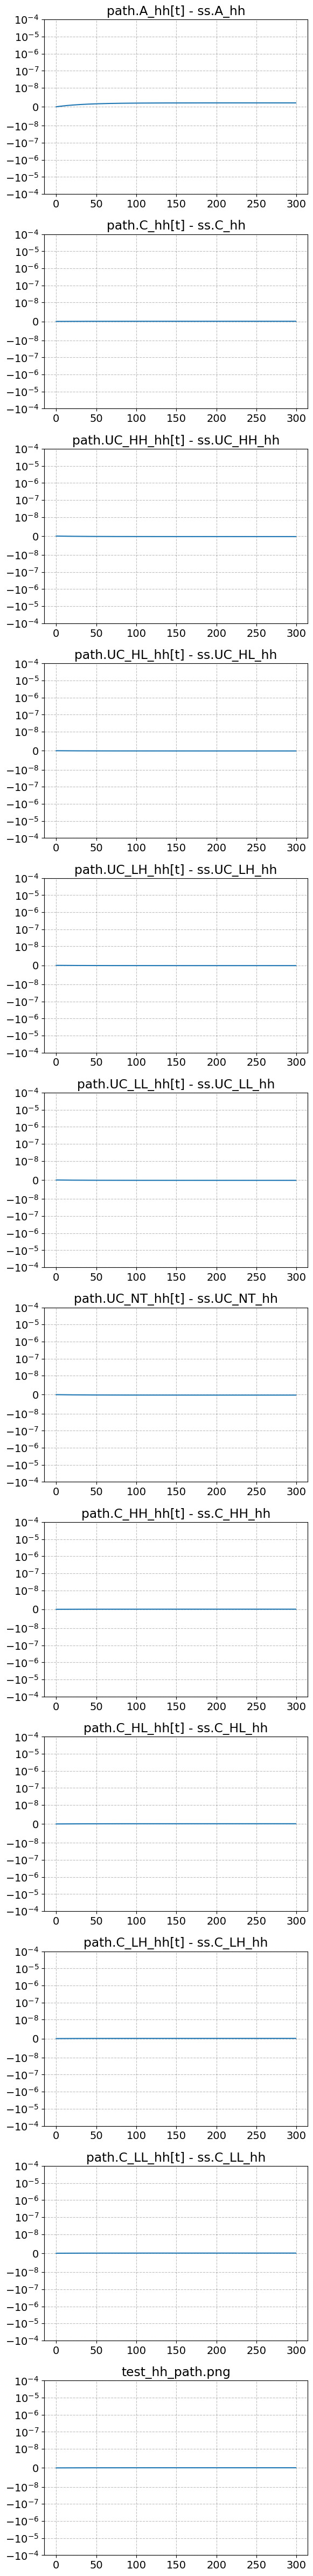

In [9]:
model.test_hh_path()
#Saving figure
plt.title("test_hh_path.png")
plt.savefig(os.path.join(folder_us, "test_hh_path.png"), dpi=300, bbox_inches="tight")

In [ ]:
model.test_path()

## 3. <a id='toc4_'></a>[Steady state values / Distributions](#toc0_)

## Distributions

In [ ]:
#MPC
MPC = np.sum(ss.D[:,:,:-1]*(ss.c[:,:,1:]-ss.c[:,:,:-1])/((1+ss.r)*(par.a_grid[1:]-par.a_grid[:-1])))
print(f'{MPC:.2f}')

0.19


FileNotFoundError: [Errno 2] No such file or directory: 'US extension\\cons_saving.png'

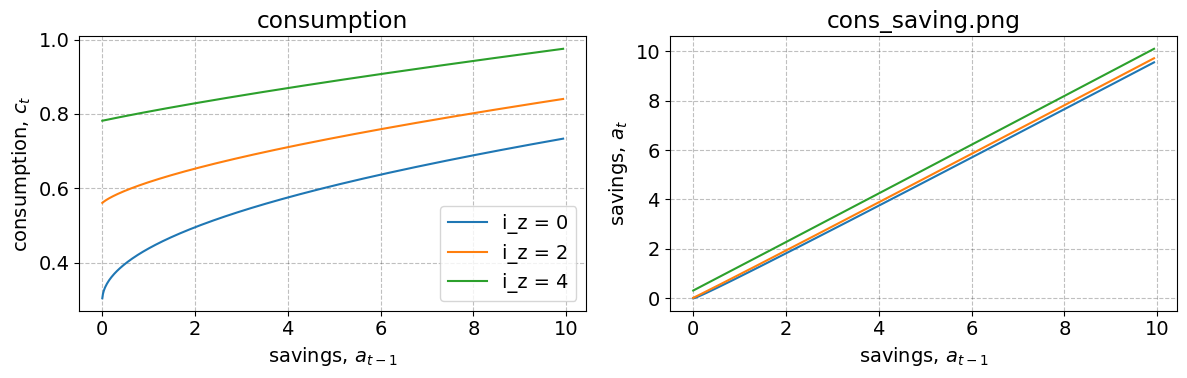

In [ ]:
fig = plt.figure(figsize=(18,4),dpi=100)
a_max = 10

# a. consumption
I = par.a_grid < a_max

ax = fig.add_subplot(1,3,1)
ax.set_title(f'consumption')

for i_z in [0,par.Nz//2,par.Nz-1]:
    ax.plot(par.a_grid[I],ss.c[0,i_z,I],label=f'i_z = {i_z}')

ax.legend(frameon=True)
ax.set_xlabel('savings, $a_{t-1}$')
ax.set_ylabel('consumption, $c_t$')

# b. saving
I = par.a_grid < a_max

ax = fig.add_subplot(1,3,2)
ax.set_title(f'saving')

for i_z in [0,par.Nz//2,par.Nz-1]:
    ax.plot(par.a_grid[I],ss.a[0,i_z,I],label=f'i_z = {i_z}')

ax.set_xlabel('savings, $a_{t-1}$')
ax.set_ylabel('savings, $a_{t}$')

fig.tight_layout()
#Saving figure
plt.title("cons_saving.png")
plt.savefig(os.path.join(folder_us, "cons_saving.png"), dpi=300, bbox_inches="tight")


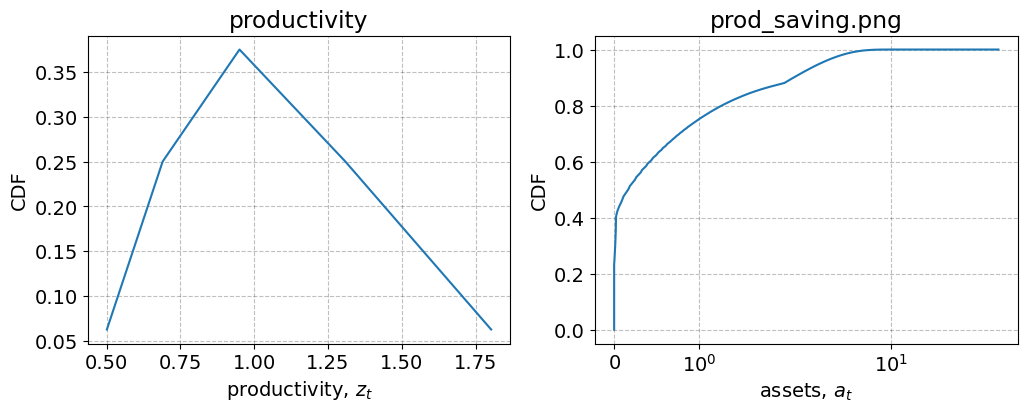

In [ ]:
fig = plt.figure(figsize=(12,4),dpi=100)

# a. income
ax = fig.add_subplot(1,2,1)
ax.set_title('productivity')

y = np.sum(ss.D[0],axis=1)
ax.plot(par.z_grid,y/y.sum())

ax.set_xlabel('productivity, $z_{t}$')
ax.set_ylabel('PDF')

# b. assets
ax = fig.add_subplot(1,2,2)
ax.set_title('savings')
y = np.insert(np.cumsum(np.sum(ss.D[0],axis=0)),0,0.0)
ax.plot(np.insert(par.a_grid,0,par.a_grid[0]),y/y[-1])
        
ax.set_xlabel('assets, $a_{t}$')
ax.set_ylabel('CDF')
ax.set_xscale('symlog')
#Saving figure
plt.title("prod_saving.png")
plt.savefig(os.path.join(folder_us, "prod_saving.png"), dpi=300, bbox_inches="tight")

[0.50078571 0.68982269 0.95021749 1.30890633 1.80299331]
[0.0625 0.25   0.375  0.25   0.0625]


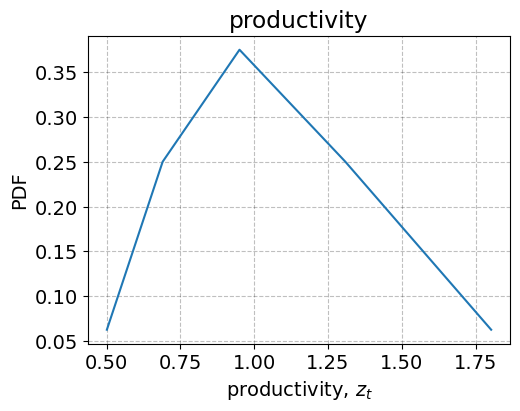

In [ ]:
fig = plt.figure(figsize=(12,4),dpi=100)

# a. income
ax = fig.add_subplot(1,2,1)
ax.set_title('productivity')

y = np.sum(ss.D[0],axis=1)
ax.plot(par.z_grid,y/y.sum())

ax.set_xlabel('productivity, $z_{t}$')
ax.set_ylabel('PDF')

print(par.z_grid)
print(y/y.sum())

## 3. <a id='toc3_'></a>[Compute Jacobians](#toc0_)

**Jacobians:**

In [3]:
model.compute_jacs(do_print=True)

household Jacobians:
one step deviation from steady state calculated in 0.0 secs
curly_Y and curly_D calculated for beta            in 0.8 secs
curly_Y and curly_D calculated for inc_HH          in 0.9 secs
curly_Y and curly_D calculated for inc_HL          in 0.8 secs
curly_Y and curly_D calculated for inc_LH          in 0.9 secs
curly_Y and curly_D calculated for inc_LL          in 1.0 secs
curly_Y and curly_D calculated for inc_NT          in 0.9 secs
curly_Y and curly_D calculated for ra              in 0.9 secs
curly_E calculated in 2.2 secs
builiding blocks combined in 1.1 secs
household Jacobian computed in 9.4 secs

full Jacobians:
full Jacobian to unknowns computed in 2.0 mins 30 secs [in evaluate_blocks(): 2.0 mins 3 secs]
full Jacobian to shocks computed in 28.6 secs [in evaluate_blocks(): 18.7 secs]
